# 11. Concentration response

[5. Hits and effects](05_hits_and_effects.ipynb) asked whether a treatment did anything. This page asks how much
of it was needed, and what the cell did on the way there.

The dataset is [the OASIS pilot](../datasets/oasis_pilot.ipynb). OASIS is a liver toxicity screen: its main cell
line is HepaRG, a hepatic progenitor line that differentiates into hepatocyte-like cells and keeps much of the
drug-metabolising machinery a real liver has. That is the point of using it — a compound that only becomes toxic
after the liver metabolises it will not show up in a cell line that cannot metabolise it. Thirty-six compounds
were dosed over ten concentrations, a three-fold ladder from 15 nM to 300 uM, with eight replicate wells at each
concentration spread over eight plates.

Three things make a dose series harder than a single-concentration screen:

- Most compounds never plateau inside the tested range, so a four-parameter logistic has no EC50 to find.
- Distance from the controls grows when a compound kills cells, which is a different finding from a phenotype.
- Most of the ladder is usually empty. You screen three decades because you do not know where the compound's
  effective range is, so the concentrations below it and, sometimes, above it carry nothing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.oasis_pilot()
# EMPTY wells hold no compound and no vehicle, so they are neither treatment nor control.
adata = adata[adata.obs["Metadata_Compound"].astype(str) != "EMPTY"].copy()
heparg = adata[adata.obs["Metadata_CellLine"] == "HepaRG"].copy()
heparg

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/IN9GYQN4/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 2831 × 99
    obs: 'Metadata_plate_map_name', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_ConcentrationNominal', 'Metadata_CellLine', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## The usual preparation

Nothing here is specific to dose response: normalize each plate against its own controls, drop the features with
no spread among those controls, then select features.

In [2]:
mt.pp.normalize(heparg, by="Metadata_Plate", reference="negcon")
heparg = heparg[:, ~heparg.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(heparg, na_cutoff=0.0)
heparg = mt.pp.subset_features(heparg)
print(f"{heparg.n_obs} wells, {heparg.n_vars} features kept")

2831 wells, 99 features kept


## A mantispy object is an AnnData object

scanpy works on it directly. The PCA, the neighbour graph and the UMAP below come from scanpy; the colours come
from the columns `mt.ds.oasis_pilot` attached.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_1605/992733786.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


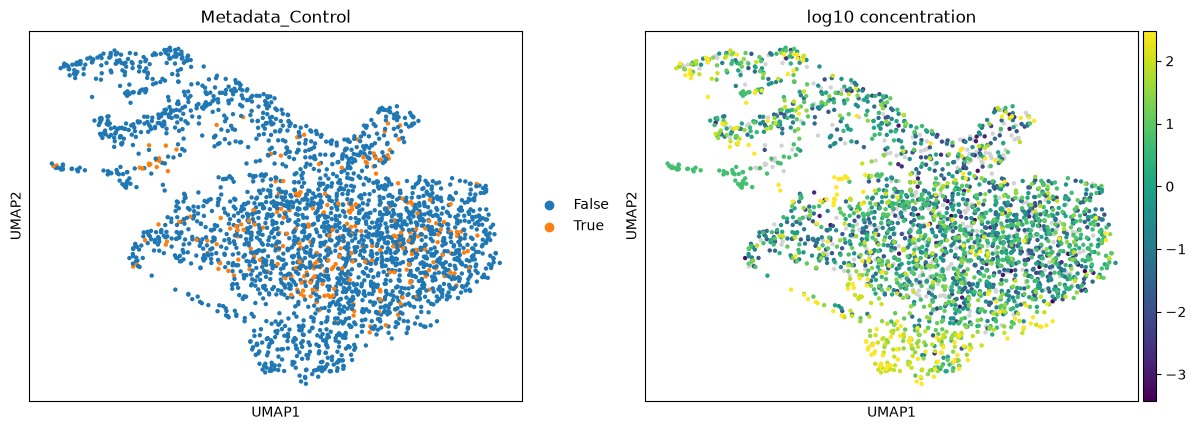

In [3]:
sc.pp.pca(heparg, n_comps=20)
sc.pp.neighbors(heparg)
sc.tl.umap(heparg)

heparg.obs["log10 concentration"] = np.log10(heparg.obs["Metadata_Concentration"].replace(0, np.nan))
sc.pl.umap(heparg, color=["Metadata_Control", "log10 concentration"], size=40, ncols=2, show=False)
plt.tight_layout()

The controls sit together and the highest concentrations sit furthest from them, which is the shape a dose series
should have before any statistics are run.

## From profiles to a response per well

{func}`~mantispy.tl.hit_calling` writes two columns. `hits_distance` is the group's statistic repeated over its
rows; `hits_row_distance` is each well's own distance from the control centroid. The curve fit needs the second:
a column that is constant within a group carries no dose information.

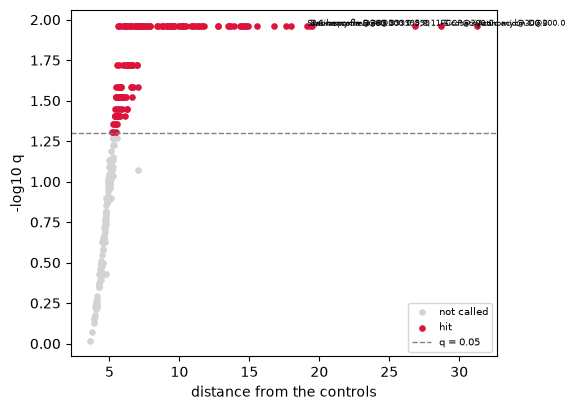

In [4]:
mt.tl.hit_calling(heparg, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
ax = mt.pl.hits(heparg, label_top=6)
plt.show()

That warning is about replication, and the answer is in which column names the groups. HepaRG carries eight
wells at each concentration, but only because `Metadata_Perturbation` is built from
`Metadata_ConcentrationNominal`: two of this accession's twelve plate maps write the dose to three decimals and
the rest to four, so on the raw `Metadata_Concentration` a treatment's replicates split across two spellings.
U2OS is two plates rather than eight, and there most groups really do hold one or two wells.

Every dose call below is given the nominal column for the same reason.

## Fitting the concentration response

In [5]:
mt.tl.dose_response(heparg, compound_key="Metadata_Compound", dose_key="Metadata_ConcentrationNominal", min_doses=4)
curves = heparg.uns["mantispy"]["dose_response"].set_index("compound")
curves = curves[curves.index.astype(str) != "DMSO"]
curves.sort_values("hitcall", ascending=False).head(8)[
    ["n_doses", "spearman", "qvalue", "ec50", "r_squared", "fit_ok", "hitcall", "hitcall_model"]
]

,n_doses,spearman,qvalue,ec50,r_squared,fit_ok,hitcall,hitcall_model
compound,,,,,,,,
Staurosporine,10,0.598735,4.160661e-08,2.392498e-01,0.131875,False,1.000000,linear
Actinomycin D,10,0.435906,9.290771e-05,1.002435e+02,0.106392,False,0.999999,logistic
Fluazinam,10,0.578382,1.346795e-07,1.972653e+01,0.378007,False,0.999998,logistic
FCCP,10,0.669596,3.118984e-10,2.245102e+08,0.622102,False,0.999998,linear
"5,8,11-Eicosatriynoic acid",10,0.387472,5.972081e-04,1.989348e+07,0.481171,False,0.999998,linear
"5,6-benzoflavone",10,0.511855,3.266517e-06,3.743672e+01,0.614839,False,0.999997,logistic
Cucurbitacin I,10,0.515813,3.031965e-06,3.517756e+01,0.171158,False,0.999996,linear
CLIOQUINOL,10,0.604766,3.966933e-08,7.560443e+01,0.544926,False,0.999996,logistic


Three columns answer three different questions.

`spearman` with its `qvalue` asks whether the response rises with dose at all. It assumes no shape and works with
three points.

`fit_ok` asks whether the logistic converged on something curve-shaped with an EC50 inside the tested range. It is
`False` for most compounds here: a compound still climbing at the top concentration has no EC50 in range, so no
potency should be quoted for it.

`hitcall` asks whether the response is large next to the noise the controls carry. It is the product of three
confidences from the ToxCast pipeline: that the curve beats a flat fit, that some concentration's median clears
the cutoff, and that the fitted top clears it. The cutoff is three times the controls' MAD unless you pass one.
`hitcall_model` names the shape that won: `logistic` where the curve plateaus, `linear` where it is still
climbing. Note that it saturates at 1.0 for the strongest compounds, so it separates active from inactive but
does not rank the actives against each other.

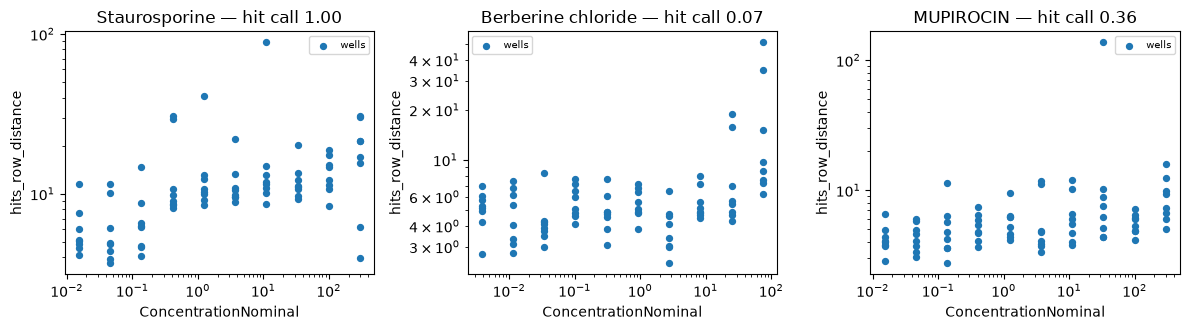

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, compound in zip(axes, ["Staurosporine", "Berberine chloride", "MUPIROCIN"], strict=False):
    mt.pl.dose_response(heparg, compound=compound, dose_key="Metadata_ConcentrationNominal", ax=ax)
    ax.set_title(f"{compound} — hit call {curves['hitcall'].get(compound, float('nan')):.2f}")
fig.tight_layout()

Staurosporine is a broad-spectrum kinase inhibitor and the standard positive control in cell painting; it climbs
far past the band. Mupirocin inhibits bacterial isoleucyl-tRNA synthetase and has no target in a human cell, so
it never leaves it. Berberine barely leaves it either in this cell line.

## Which features move, and at what concentration

The curve above reads one number per well, its distance from the controls. That number says a compound did
something; it does not say what. {func}`~mantispy.tl.dose_features` asks the same question of every feature and
reports the lowest concentration at which each one's median response reaches three times the spread the controls
show on it.

That is a benchmark dose rather than an EC50. An EC50 needs a plateau, and most compounds here never reach one.
A benchmark dose only needs the response to cross a line the controls set, so it is defined for a feature that is
still climbing at the top concentration. The ToxCast pipeline reads its `3 * bmad` the same way.

In [7]:
mt.tl.dose_features(heparg, dose_key="Metadata_ConcentrationNominal")
features = heparg.uns["mantispy"]["dose_features"]
# bmd is NaN for a feature that never crosses the cutoff, so dropna leaves the ones that responded.
active = features[features["compound"] == "Staurosporine"].dropna(subset=["bmd"])
print(f"{len(active)} of {features['feature'].nunique()} features respond to staurosporine")
active.sort_values("bmd").head(8)[["feature", "bmd", "max_z", "direction", "spearman", "qvalue"]]

30 of 99 features respond to staurosporine


,feature,bmd,max_z,direction,spearman,qvalue
2504,Cytoplasm_AreaShape_Zernike_1_1,0.336326,3.445138,1.0,0.066715,0.655931
2510,Cytoplasm_AreaShape_Zernike_6_2,0.362425,4.209308,1.0,0.313785,0.012627
2547,Nuclei_Correlation_Overlap_AGP_DNA,0.368587,3.983743,-1.0,-0.218047,0.099024
2507,Cytoplasm_AreaShape_Zernike_5_1,0.397131,4.653107,1.0,0.313973,0.012627
2477,Cells_AreaShape_Zernike_2_0,0.452530,3.777016,1.0,0.300500,0.017164
2555,Nuclei_RadialDistribution_FracAtD_DNA_3of4,0.467579,5.298065,1.0,0.518075,0.000017
2509,Cytoplasm_AreaShape_Zernike_6_0,0.760266,3.965238,1.0,0.296635,0.018215
2531,Cytoplasm_RadialDistribution_MeanFrac_Brightfi...,0.788061,3.821740,-1.0,-0.559913,0.000002


The features that move first are shape and spatial-distribution measurements, not intensity ones.

`Cytoplasm_AreaShape_Zernike_*` are Zernike moments: an orthogonal decomposition of the cytoplasm outline, so a
change means the cells are changing shape rather than getting brighter. `Nuclei_RadialDistribution_FracAtD_DNA_3of4`
is the fraction of the DNA signal falling in the third of four concentric rings measured out from the nucleus
centre — chromatin moving toward the nuclear periphery, which is what condensing chromatin does.

`spearman` and `bmd` disagree in the first row. A monotone trend across the whole range and a threshold crossing
are different questions: a feature that steps up early and then flattens has a low Spearman and a low benchmark
dose. A crossing with no trend behind it is the weakest evidence in the table.

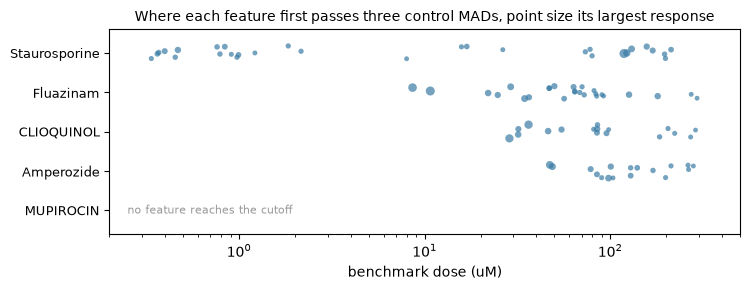

In [8]:
shown = ["MUPIROCIN", "Amperozide", "CLIOQUINOL", "Fluazinam", "Staurosporine"]
jitter = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7.6, 3.0))
for row, compound in enumerate(shown):
    block = features[features["compound"] == compound].dropna(subset=["bmd"])
    if block.empty:
        ax.text(0.25, row, "no feature reaches the cutoff", fontsize=8, va="center", color="#999999")
        continue
    ax.scatter(
        block["bmd"],
        row + jitter.uniform(-0.18, 0.18, len(block)),
        s=4 * block["max_z"],
        color="#3a7ca5",
        alpha=0.7,
        edgecolor="none",
    )
ax.set_xscale("log")
ax.set_xlim(0.2, 500)
ax.set_ylim(-0.6, len(shown) - 0.4)
ax.set_xlabel("benchmark dose (uM)")
ax.set_yticks(range(len(shown)), shown, fontsize=9)
ax.set_title("Where each feature first passes three control MADs, point size its largest response", fontsize=10)
fig.tight_layout()

The potencies span three orders of magnitude: staurosporine moves a feature at 0.34 uM, fluazinam at 8.6,
clioquinol at 29, amperozide at 47. Mupirocin moves none of the 99, which is what a compound with no mammalian
target should do and is the check that the cutoff is set sensibly.

Two features recur near the front of amperozide, clioquinol and fluazinam:
`Nuclei_Correlation_Correlation_Brightfield_DNA` and `Cells_Correlation_Overlap_DNA_Mito`. Both measure how far
two channels agree with each other rather than how much of either there is, and channel agreement rises whenever
segmentation starts to struggle — in a rounding or dying cell, every stain collapses into the same small region.
For staurosporine the same two features rank twenty-first and ninth, so its early response is not that. Shared
responsive features across compounds are a reason to look at the direction, not yet evidence of a shared
mechanism.

## The same phenotype, or a different one?

A distance from the controls grows for two reasons that mean different things: the same phenotype gets stronger,
or a different one takes over. Distance cannot separate them, because it discards the direction.

{func}`~mantispy.tl.dose_direction` keeps the direction. Each concentration gets `amplitude`, how far its median
profile sits from the controls in MADs per feature; `split_half_cosine`, the cosine between the directions the
two halves of its replicate plates point in; and `cosine_to_top`, the cosine against the highest concentration's
profile. `amplitude_null` is what control wells spread over the same plates in the same numbers reach.

Read together: a concentration whose plate halves disagree has no direction at all, however large its amplitude.
One whose halves agree but which points away from the top concentration is a real phenotype, and a different one.

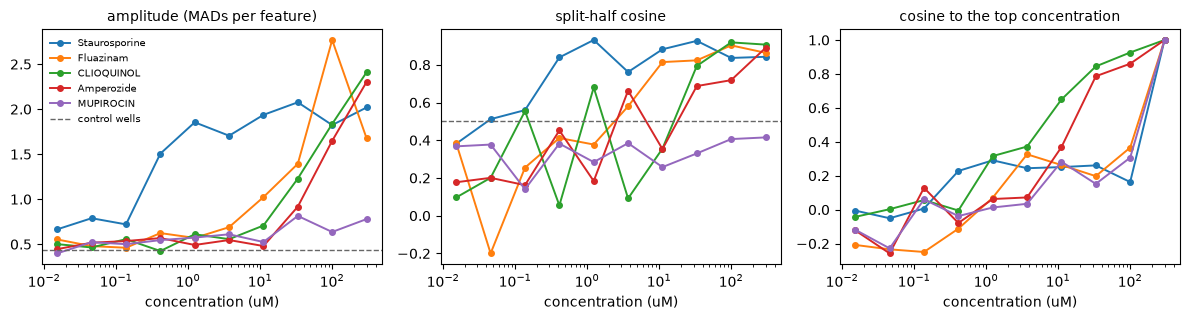

In [9]:
mt.tl.dose_direction(heparg, dose_key="Metadata_ConcentrationNominal")
direction = heparg.uns["mantispy"]["dose_direction"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharex=True)
for compound in shown[::-1]:
    block = direction[direction["compound"] == compound].sort_values("dose")
    for ax, column in zip(axes, ["amplitude", "split_half_cosine", "cosine_to_top"], strict=True):
        ax.plot(block["dose"], block[column], marker="o", ms=4, lw=1.4, label=compound)

axes[0].axhline(direction["amplitude_null"].median(), ls="--", lw=1, color="0.4", label="control wells")
axes[1].axhline(0.5, ls="--", lw=1, color="0.4")
titles = ["amplitude (MADs per feature)", "split-half cosine", "cosine to the top concentration"]
for ax, title in zip(axes, titles, strict=True):
    ax.set_xscale("log")
    ax.set_xlabel("concentration (uM)")
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=7, frameon=False)
fig.tight_layout()

Amperozide and clioquinol are the simple case. Nothing happens below about 30 uM, and then the amplitude climbs
to 2.3 and 2.4 MADs per feature with `cosine_to_top` climbing alongside it to 0.86 and 0.93 at 100 uM. One
phenotype, arriving late and getting stronger. A single number per concentration loses nothing for these two.

Staurosporine is the case a single number hides. Its amplitude reaches 1.5 at 0.41 uM and then stops: 1.9 at
1.2 uM, 2.1 at 33, 2.0 at 300. As a distance it saturates two decades below the top of the range. But its plate
halves agree from 0.41 uM on, 0.76 and above, so each of those concentrations has a direction that reproduces —
and `cosine_to_top` stays between 0.16 and 0.29. The cell is doing something different at 0.41 uM than at 300 uM.
The next section shows what.

Fluazinam is an uncoupler of mitochondrial oxidative phosphorylation. Its halves agree from 11 uM, `cosine_to_top`
stays at or below 0.37 throughout, and its amplitude falls from 2.8 to 1.7 between 100 and 300 uM. Its top well
is doing something this page does not resolve.

Mupirocin sits on the floor: amplitude between 0.40 and 0.81 against a null of 0.43, and no concentration whose
halves agree above 0.41. Its 33 uM well reaches nearly twice the null amplitude with no reproducible direction,
which is why amplitude alone is not enough to call a response.

### What staurosporine's two phenotypes are

`cosine_to_top` says the direction turns. It does not say into what. Each column of `heparg.X` is already scaled
against its own plate's controls, so the median of a concentration's wells reads directly in control MADs and the
features can be plotted against dose.

Group on `Metadata_ConcentrationNominal` rather than the raw column, for the reason given above: the batches
write the same concentration to different precision, and grouping on the raw values alternates between them at
every step of the ladder.


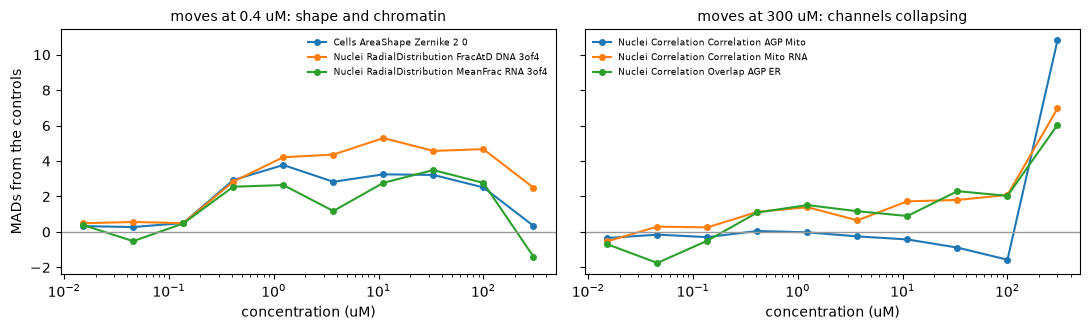

In [10]:
early = [
    "Cells_AreaShape_Zernike_2_0",
    "Nuclei_RadialDistribution_FracAtD_DNA_3of4",
    "Nuclei_RadialDistribution_MeanFrac_RNA_3of4",
]
late = [
    "Nuclei_Correlation_Correlation_AGP_Mito",
    "Nuclei_Correlation_Correlation_Mito_RNA",
    "Nuclei_Correlation_Overlap_AGP_ER",
]

stauro = heparg[heparg.obs["Metadata_Compound"] == "Staurosporine"]
traces = pd.DataFrame(np.asarray(stauro[:, early + late].X), columns=early + late)
traces["dose"] = stauro.obs["Metadata_ConcentrationNominal"].to_numpy(dtype=float)
traces = traces.groupby("dose").median()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, group, title in zip(
    axes, [early, late], ["moves at 0.4 uM: shape and chromatin", "moves at 300 uM: channels collapsing"], strict=True
):
    for feature in group:
        ax.plot(traces.index, traces[feature], marker="o", ms=4, lw=1.5, label=feature.replace("_", " "))
    ax.axhline(0, color="0.6", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("concentration (uM)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=6.5, frameon=False)
axes[0].set_ylabel("MADs from the controls")
fig.tight_layout()

Two different things, at two different concentrations.

At 0.4 uM the cells change shape and their chromatin and RNA move outward: a Zernike moment of the cell outline,
the fraction of DNA signal in the outer rings of the nucleus, the same for RNA. That is the morphology of a cell
that has rounded up and condensed its chromatin, which is what broad kinase inhibition does before anything else.
These three then change little across the remaining two and a half decades, and fall back at the very top
concentration.

At 300 uM a different set takes over, and all of them are channel-to-channel correlations inside the nucleus
region: AGP against Mito, Mito against RNA, AGP against ER. AGP is the actin, Golgi and plasma-membrane stain.
Every stain agreeing with every other stain in the same place is not a phenotype in the usual sense — it is what
the image looks like when the cell has lost its internal organisation and the compartments no longer separate.
`Nuclei_Correlation_Correlation_AGP_Mito` reaches 10.8 MADs.

So the distance saturating at 0.4 uM while the direction keeps turning is a real biological sequence: the
kinase-inhibition phenotype arrives first and stops, and cell disintegration takes over later. Two features
actually reverse sign between the two, including `Nuclei_Correlation_Overlap_AGP_DNA`. A curve fitted to distance
alone reports one EC50 for both and describes neither.

## Where on the ladder is anything happening?

Every column so far describes a single concentration. None says which stretch of the ladder is worth reading.

`dose_direction` labels each concentration with a `phase`:

- `silent` — no reproducible response.
- `responding` — still moving. The step from the concentration below, `step_amplitude`, beats the noise two
  independent groups of wells carry.
- `saturated` — reproducible, but it has stopped changing.
- `cytotoxic` — more than half the cells are gone, so the profile is the morphology of dying cells whatever else
  is true of it. The US EPA's phenotypic pipeline drops these before fitting anything.

The window is a run, not a scatter. `split_half_cosine` over eight wells is itself noisy, and labelling each
concentration independently let one lucky concentration open amperozide's window at 3.7 uM instead of 33. A
response that has started does not stop, so the window is the run of concentrations reaching the highest one that
is not cytotoxic.

In [11]:
direction[direction["compound"] == "Amperozide"][
    ["dose", "amplitude", "amplitude_null", "step_amplitude", "split_half_cosine", "viability", "phase"]
].round(2)

,dose,amplitude,amplitude_null,step_amplitude,split_half_cosine,viability,phase
40,0.02,0.45,0.43,0.45,0.18,1.01,silent
41,0.05,0.52,0.43,0.65,0.20,1.02,silent
42,0.14,0.54,0.43,0.57,0.16,0.92,silent
43,0.41,0.57,0.43,0.82,0.45,0.91,silent
44,1.23,0.49,0.43,0.59,0.18,0.98,silent
45,3.70,0.55,0.43,0.60,0.66,0.94,silent
46,11.11,0.48,0.43,0.60,0.35,0.97,silent
47,33.33,0.92,0.43,0.86,0.69,1.05,responding
48,100.00,1.65,0.43,1.17,0.72,0.85,responding
49,300.00,2.30,0.43,1.22,0.89,0.77,responding


{func}`~mantispy.pl.dose_direction` draws that reading. The solid line is how far the profile sits from the
controls and the dashed line is how far it moved from the concentration below, which is the one that says where
the action is. The background is banded by phase.

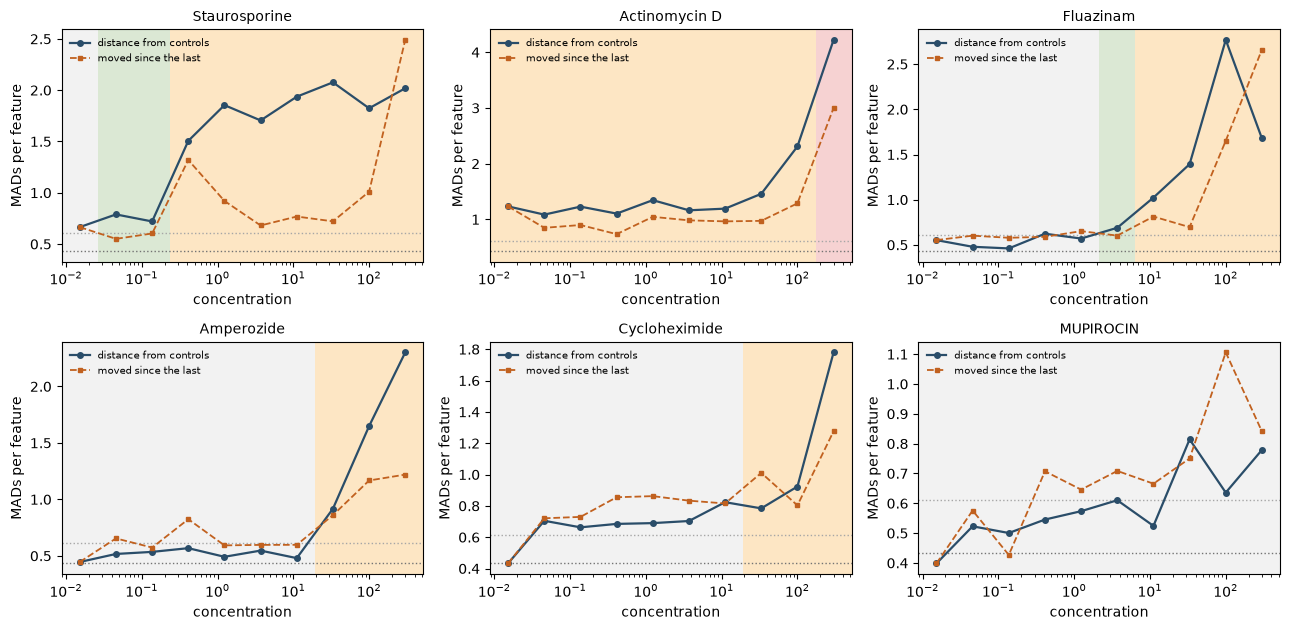

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))
for ax, compound in zip(
    axes.ravel(),
    ["Staurosporine", "Actinomycin D", "Fluazinam", "Amperozide", "Cycloheximide", "MUPIROCIN"],
    strict=True,
):
    mt.pl.dose_direction(heparg, compound=compound, ax=ax)
fig.tight_layout()

Mupirocin is grey the whole way. Amperozide and cycloheximide are grey until about 20 uM and then respond to the
top, so seven of their ten concentrations sit below their effective range — which is the expected result of
covering three decades to find a window you cannot predict, not a wasted experiment.

Staurosporine responds from 0.41 uM to the top without settling, which is the turning direction above seen from
another side: a compound whose step never falls back to the noise has not finished changing. The two
concentrations below that are `saturated` — reproducible, but not moving.

Actinomycin D is responding at the lowest concentration tested. It intercalates DNA and blocks RNA polymerase at
nanomolar concentrations, so 15 nM is already well inside its range and its onset lies below this ladder — the
screen cannot say where. Its viability declines steadily from 0.77 to 0.48 across the range, and only the 300 uM
well falls below half, where the band turns red. Both edges of a dose series can fall outside it.

The phase lands on `obs`, so the window is an ordinary subset.

### Check the cell counts before trusting a cytotoxic call

`viability` is each well's cell count per field against **its own plate's** controls. That matters here: the eight
plates range from 484 to 708 control cells per field, so scoring against the whole screen's median would mark the
sparser plates as dying and hide real losses on the denser ones.

Per-plate normalisation is necessary but not sufficient. The pilot's HepaRG wells come from two batches, and they
do not agree about cell loss.

In [13]:
heparg.obs["batch"] = np.where(
    heparg.obs["Metadata_Plate"].astype(str).str.startswith("BR001478"), "Ptx_AD2", "HepaRG_AD"
)
control = heparg.obs["Metadata_Control"].to_numpy(dtype=bool)
per_field = heparg.obs["Metadata_CellCount"] / heparg.obs["Metadata_SiteCount"]

print("control cells per field, by plate:")
print(per_field[control].groupby(heparg.obs["Metadata_Plate"][control], observed=True).median().round(0).to_string())

# Each well against its own plate's controls, which is what dose_direction's viability column is.
reference = per_field[control].groupby(heparg.obs["Metadata_Plate"][control], observed=True).median()
viability = per_field / heparg.obs["Metadata_Plate"].map(reference).astype(float)
print("\nviability of treated wells, by batch:")
print(
    viability[~control]
    .groupby(heparg.obs["batch"][~control])
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
    .to_string()
)

# At the bottom of the ladder nothing should have happened yet, so any gap there is not the compound.
low = ~control & (heparg.obs["Metadata_ConcentrationNominal"].to_numpy(dtype=float) < 0.2)
print("\nviability below 0.2 uM, by batch:")
print(viability[low].groupby(heparg.obs["batch"][low]).median().round(2).to_string())

control cells per field, by plate:
Metadata_Plate
BR00145690    587.0
BR00145691    572.0
BR00145692    524.0
BR00145693    652.0
BR00145694    597.0
BR00145695    484.0
BR00147878    696.0
BR00147879    708.0

viability of treated wells, by batch:
            count   25%   50%   75%
batch                              
HepaRG_AD  1871.0  0.90  0.98  1.05
Ptx_AD2     704.0  0.66  0.82  0.96

viability below 0.2 uM, by batch:
batch
HepaRG_AD    0.99
Ptx_AD2      0.87


Against its own plate's controls, the median treated well in the `HepaRG_AD` batch sits at 0.98 of control and
the median treated well in `Ptx_AD2` at 0.82. The gap is not dose-driven: below 0.2 uM, where almost nothing
should have happened yet, the two sit at 0.99 and 0.87. `Ptx_AD2`'s plate map also carries `cell_density` and
`culture_time` columns the other batch does not, so the two were not seeded or cultured identically.

An earlier draft of this page, which scored viability against the whole screen at once, called actinomycin D
cytotoxic above 60 uM. Per plate, only its 300 uM well is. The first version was reporting the batch, not the
compound. A cytotoxicity call is a claim about cell counts, and cell counts are the most batch-sensitive number in
a screen — check them against the plate layout before believing one.

### The point of departure

Toxicology has a name for the concentration at which a response leaves the baseline: the point of departure,
which is what a benchmark dose estimates. This page has now arrived at one twice by different routes.
{func}`~mantispy.tl.dose_features` crosses each feature against the spread the controls show on it and reports
where that happens. {func}`~mantispy.tl.dose_direction` asks when the whole profile starts moving in a direction
that reproduces across plates, and the onset of the responding window is its answer.

They are not the same construction, so whether they agree is worth checking rather than assuming.

In [14]:
onset = direction[direction["phase"] == "responding"].groupby("compound")["dose"].min()
crossings = features.dropna(subset=["bmd"]).groupby("compound")["bmd"].quantile(0.05)
departure = pd.DataFrame({"window_onset": onset, "feature_bmd_5th": crossings}).dropna()
# How far apart the two answers are, counted in steps of the three-fold ladder that was dosed.
departure["steps_apart"] = np.log10(departure["feature_bmd_5th"] / departure["window_onset"]) / np.log10(3.0)

print(
    f"{len(departure)} compounds with both | rank correlation "
    f"{departure['window_onset'].corr(departure['feature_bmd_5th'], method='spearman'):.2f} | "
    f"{int((departure['steps_apart'].abs() <= 1).sum())} within one step"
)
departure.sort_values("window_onset").round(2)

20 compounds with both | rank correlation 0.79 | 17 within one step


,window_onset,feature_bmd_5th,steps_apart
compound,,,
Actinomycin D,0.02,0.02,0.00
Staurosporine,0.41,0.37,-0.11
"5,8,11-Eicosatriynoic acid",3.70,17.96,1.44
Lys05,5.00,12.15,0.81
Calcipotriol (hydrate),11.11,13.34,0.17
FCCP,11.11,26.52,0.79
Fluazinam,11.11,13.53,0.18
Berberine chloride,25.00,45.35,0.54
Amperozide,33.33,48.44,0.34


They agree: the two rank together at 0.79, and seventeen of twenty compounds land within one three-fold step of
each other, which is all the resolution this ladder has.

Cucurbitacin I is the exception and the informative one. Its first feature crosses two steps below the
concentration at which the profile as a whole starts to reproduce. One feature out of ninety-nine passing a
three-MAD line is a weaker claim than a whole direction holding across replicate plates, and where the two
disagree the aggregate is the one to believe. Read the per-feature points of departure as the order in which
things engage, and the window onset as where the compound engages.

The phase is on `obs`, so the window is an ordinary subset and the rest of the package applies to it.


In [15]:
# The controls are in no phase, so they have to be kept deliberately: every statistic here is read against them.
responding = heparg.obs["dose_direction_phase"] == "responding"
window = heparg[responding | heparg.obs["Metadata_Control"].to_numpy(dtype=bool)].copy()
print(f"{int(responding.sum())} of {heparg.n_obs} wells are inside some compound's responding window")

# Two doses is enough here: the question is which features move inside the window, not where they cross.
mt.tl.dose_features(window, dose_key="Metadata_ConcentrationNominal", min_doses=2)
inside = window.uns["mantispy"]["dose_features"].dropna(subset=["bmd"])
inside.groupby("compound").size().sort_values(ascending=False).head(6)

576 of 2831 wells are inside some compound's responding window


compound
Staurosporine                 30
FCCP                          27
Fluazinam                     26
Calcipotriol (hydrate)        24
5,8,11-Eicosatriynoic acid    21
Amperozide                    17
dtype: int64

## Comparing compounds on what they do, not on when they do it

Two compounds compared at the same concentration are usually compared at different points of their own ranges:
at 30 uM amperozide has not started and staurosporine finished two decades ago. Comparing them at their
strongest concentration instead throws away everything on the way there, which for a compound whose phenotype
turns along its window is most of what it did.

{func}`~mantispy.tl.dose_trajectory` reads each compound's window onto the same relative axis: position 0 is
where it starts responding, position 1 is the top of its window, and the profile is interpolated in log
concentration between them. The result is an ordinary object of compounds by features-and-positions, so
{func}`~mantispy.tl.similarity` and anything else works on it.

In [16]:
paths = mt.tl.dose_trajectory(heparg, dose_key="Metadata_ConcentrationNominal", n_positions=3)
mt.tl.similarity(paths, metric="pearson")

compounds = list(paths.obs["Metadata_Compound"])
similarity = pd.DataFrame(np.asarray(paths.obsp["similarity"]), index=compounds, columns=compounds)
print(
    f"{paths.n_obs} compounds with a window of two or more concentrations, "
    f"{paths.n_vars} columns ({paths.var['feature'].nunique()} features x 3 positions)"
)
for name in ["Actinomycin D", "Staurosporine", "Fluazinam"]:
    neighbours = similarity.loc[name].drop(name).sort_values(ascending=False).head(3)
    print(f"{name:16s} -> " + ", ".join(f"{other} {value:+.2f}" for other, value in neighbours.items()))

20 compounds with a window of two or more concentrations, 297 columns (99 features x 3 positions)
Actinomycin D    -> Cycloheximide +0.46, Calcipotriol (hydrate) +0.33, FCCP +0.25
Staurosporine    -> Fluazinam +0.58, Calcipotriol (hydrate) +0.44, CLIOQUINOL +0.43
Fluazinam        -> CLIOQUINOL +0.66, Staurosporine +0.58, Amperozide +0.58


Actinomycin D's nearest neighbour is cycloheximide. One blocks transcription and the other translation, and the
cell arrives at a similar place by a similar route. Nothing in the input encodes that, and the two never share a
concentration at which both are responding.

How much the path adds over its own endpoint depends on how many concentrations fall inside the window, and a
window of two or three is the normal result of screening a wide range. Correlating the compound-by-compound matrix
built from paths against the one built from each compound's top concentration gives 0.92, which is what should
happen when most paths are two points long.

Where they disagree, they disagree sharply rather than noisily: cucurbitacin I against staurosporine is +0.25 by
path and -0.22 by endpoint. That is a different answer, not a noisier one, and it comes from the two compounds
with the longest windows.

The window also tells you what to run next. A range-finding ladder buys the location of the window; the way to
resolve it is a second ladder spaced across the concentrations this one marked `responding`, not another three
decades at the same spacing.

## Distance is not the same as phenotype

A compound that kills cells also moves away from the controls, and the curve cannot tell the two apart.
{func}`~mantispy.tl.cytotoxicity` compares each group's cells per field against the controls', so the calls can
be read beside it.

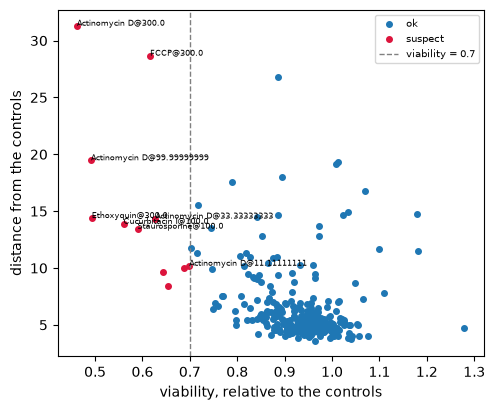

In [17]:
mt.tl.cytotoxicity(heparg, groupby="Metadata_Perturbation")
ax = mt.pl.cytotoxicity(heparg)
plt.show()

A high call with viability near one is a change in the shape of living cells. A high call with viability
collapsed is the morphology of dying cells, which most mechanisms share. The US EPA's phenotypic profiling
pipeline drops any concentration that loses more than half the cells before it fits anything, and that is a
reasonable habit here.

## Does the call survive a second cell line?

The same compounds were dosed in U2OS. The two lines were normalized and feature-selected apart, so their
distances are not on one scale, but their calls can still be compared.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_1605/443386283.py:7: UserWarning: 280 of 289 groups have fewer than three rows, so their statistic is the median of one or two wells. Aggregate more replicates, or score activity with mt.tl.map(mode='activity'), which ranks replicate pairs and is built for screens with little replication.
  mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)


28 shared compounds, 61% called the same way in both


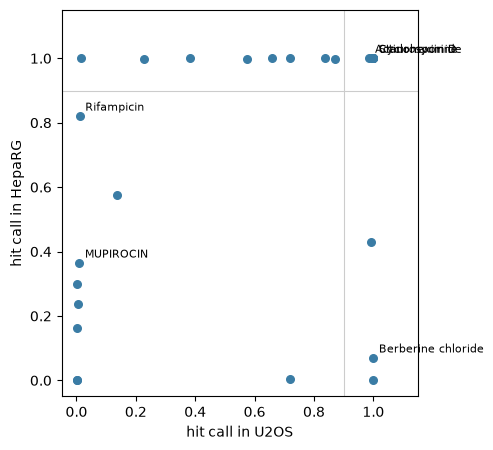

In [18]:
u2os = adata[adata.obs["Metadata_CellLine"] == "U2OS"].copy()
mt.pp.normalize(u2os, by="Metadata_Plate", reference="negcon")
u2os = u2os[:, ~u2os.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(u2os, na_cutoff=0.0)
u2os = mt.pp.subset_features(u2os)
sc.pp.pca(u2os, n_comps=20)
mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
mt.tl.dose_response(u2os, compound_key="Metadata_Compound", dose_key="Metadata_ConcentrationNominal", min_doses=4)

other = u2os.uns["mantispy"]["dose_response"].set_index("compound")
both = pd.DataFrame({"U2OS": other["hitcall"], "HepaRG": curves["hitcall"]}).dropna()

fig, ax = plt.subplots(figsize=(5, 4.6))
ax.scatter(both["U2OS"], both["HepaRG"], s=30, color="#3a7ca5", zorder=3)
for compound in ["Staurosporine", "Actinomycin D", "Cycloheximide", "MUPIROCIN", "Rifampicin", "Berberine chloride"]:
    if compound in both.index:
        ax.annotate(
            compound,
            (both.loc[compound, "U2OS"], both.loc[compound, "HepaRG"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )
ax.axvline(0.9, color="0.8", lw=0.8, zorder=0)
ax.axhline(0.9, color="0.8", lw=0.8, zorder=0)
ax.set(xlabel="hit call in U2OS", ylabel="hit call in HepaRG", xlim=(-0.05, 1.15), ylim=(-0.05, 1.15))
print(
    f"{len(both)} shared compounds, "
    f"{((both['U2OS'] >= 0.9) == (both['HepaRG'] >= 0.9)).mean():.0%} called the same way in both"
)
fig.tight_layout()

The corners carry the biology. Staurosporine, actinomycin D and cycloheximide inhibit kinases, transcription and
translation, and are called in both lines. Mupirocin and rifampicin are antibacterials with no mammalian target,
and are called in neither. Berberine sits off the diagonal, called in U2OS and not in HepaRG, which is a
statement about two cell types rather than a failure of the fit.

## Summary

- Use `hits_row_distance` as the response, not `hits_distance`. The group column is one number repeated over its
  wells.
- `fit_ok` and `hitcall` answer different questions. Quote an EC50 only when `fit_ok` is `True`; use `hitcall` to
  decide whether anything happened at all, not to rank what did.
- Find the window before reading anything in it. `phase` marks where a compound is silent, still changing,
  settled, or past the point where its cells are alive.
- Read the features, not only the distance. {func}`~mantispy.tl.dose_features` gives each one a benchmark dose,
  which is defined for a feature still climbing at the top concentration, where an EC50 is not.
- A distance that plateaus does not mean the phenotype stopped changing. Staurosporine's stops moving at 0.4 uM
  and keeps turning to 300, from a kinase-inhibition morphology into cell disintegration.
- Amplitude alone overcalls. Mupirocin's 33 uM well sits at nearly twice the control floor with no direction that
  reproduces across plates.
- Score viability against each plate's own controls, and check the batches agree before calling anything
  cytotoxic.
- Compare compounds on their own relative dose axis with {func}`~mantispy.tl.dose_trajectory`. At a shared
  concentration you are comparing one compound that has engaged against one that has not.
- A call that holds in a second cell line is worth more than a small q-value in one.